# AlexNet Benchmark

use PY310, py311 not support torch.compile, py39 not support libnvrtc.so compatibility

In [1]:
model_name = "ResNet152-torch"

import torch
from torch import nn
from torchvision import models
#import torch_mlir
import numpy as np
import iree
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll


In [2]:
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=33):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Experimental

In [3]:
import torch
from torch import nn
from torchvision import models
import pandas as pd

MAGIC_NUM = 7777e-5

device = torch.device("cuda:0")
model = models.squeezenet1_0().train(False)
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})
model = model.to(device)


### PyTorch (Baseline)

In [4]:
image = torch.randn(1, 3, 224, 224, requires_grad=True)
image = image.to(device)
output = model(image)
grad = torch.randn_like(output)

df = pd.DataFrame()

baseline_f = torch_model_benchmark(model, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=33, 
                                 measure_count=11)
print('torch-native-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=33, 
                                 measure_count=11)
#baseline_b = timeit("torch.autograd.grad(output_native, [image], grad, retain_graph=True)")
print('torch-native-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Native")])
print(df)

torch-native-gpu-forward:  [1.4189780887329215, 1.4129107761563677, 1.4144555580886926, 1.4099560565117633, 1.4111613854765892, 1.4102316997719533, 1.4125616430784718, 1.4126481714122223, 1.4106206539453883, 1.4128272675655105, 1.409581693058664]
1.412357544890777
torch-native-gpu-backward:  [0.9849886833266778, 0.990410956243674, 0.989258120005781, 0.9899300269105218, 0.9929752259543447, 0.9928638059081454, 0.991595908999443, 0.9909704835577445, 0.9916292955026481, 0.9899892364487503, 0.9897730285019586]
0.9903986155781536
       time      pass          item
0  1.412358   Forward  Torch Native
0  0.990399  Backward  Torch Native
0  2.402756      Full  Torch Native


In [5]:

model_dynamo = torch.compile(model, backend="inductor")

image = torch.randn(1, 3, 224, 224, requires_grad=True)
image = image.to(device)

output = model_dynamo(image)
grad = torch.randn_like(output)

image_np = image.detach().cpu().numpy()
grad_np = grad.cpu().numpy()

baseline_f = torch_model_benchmark(model_dynamo, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=111, 
                                 measure_count=11)
print('torch-dynamo-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=111, 
                                 measure_count=11)
print('torch-dynamo-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])
print(df)

torch-dynamo-gpu-forward:  [1.2572537100798373, 1.2502101677897814, 1.250648761990371, 1.2518081746928327, 1.2497065907663054, 1.2525593241055806, 1.2470410532645277, 1.2484459827343624, 1.2462658824415895, 1.239415149095359, 1.2407987840003796]
1.2485594164509932
torch-dynamo-gpu-backward:  [1.842702092888119, 1.8419262004999426, 1.846137481766778, 1.84575782937778, 1.8458216459498749, 1.8437400141412073, 1.8439335362599776, 1.8454875864155658, 1.8455035699246167, 1.8388138714808602, 1.8390956594868821]
1.8435381352901459
       time      pass          item
0  1.412358   Forward  Torch Native
0  0.990399  Backward  Torch Native
0  2.402756      Full  Torch Native
0  1.248559   Forward  Torch Dynamo
0  1.843538  Backward  Torch Dynamo
0  3.092098      Full  Torch Dynamo


In [6]:
df.style.hide(axis="index")

time,pass,item
1.412358,Forward,Torch Native
0.990399,Backward,Torch Native
2.402756,Full,Torch Native
1.248559,Forward,Torch Dynamo
1.843538,Backward,Torch Dynamo
3.092098,Full,Torch Dynamo


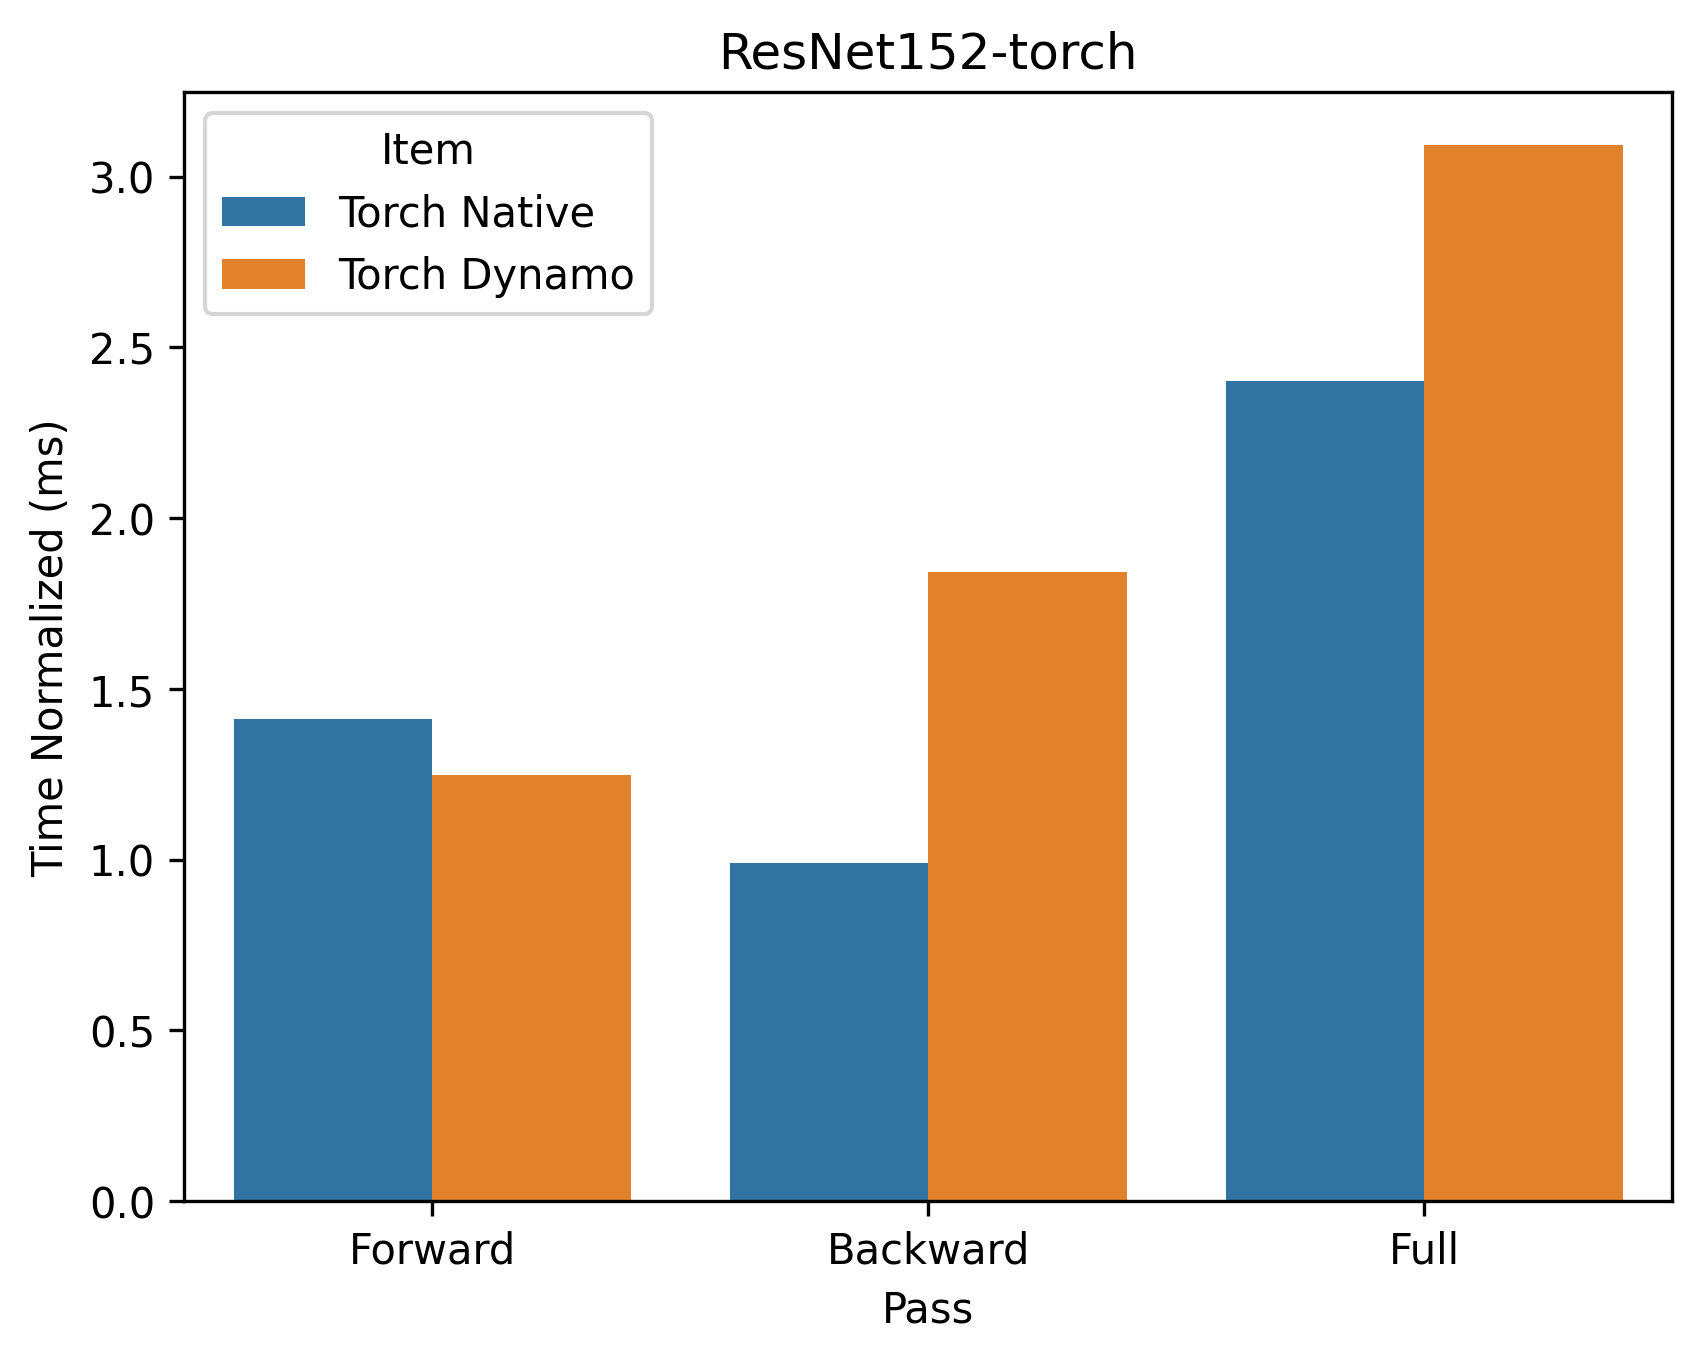

In [7]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [8]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,1.412358,Forward,Torch Native,0.884025
0,1.248559,Forward,Torch Dynamo,1.000000


In [9]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,0.990399,Backward,Torch Native,1.86141
0,1.843538,Backward,Torch Dynamo,1.00000


In [10]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,2.402756,Full,Torch Native,1.286896
0,3.092098,Full,Torch Dynamo,1.000000


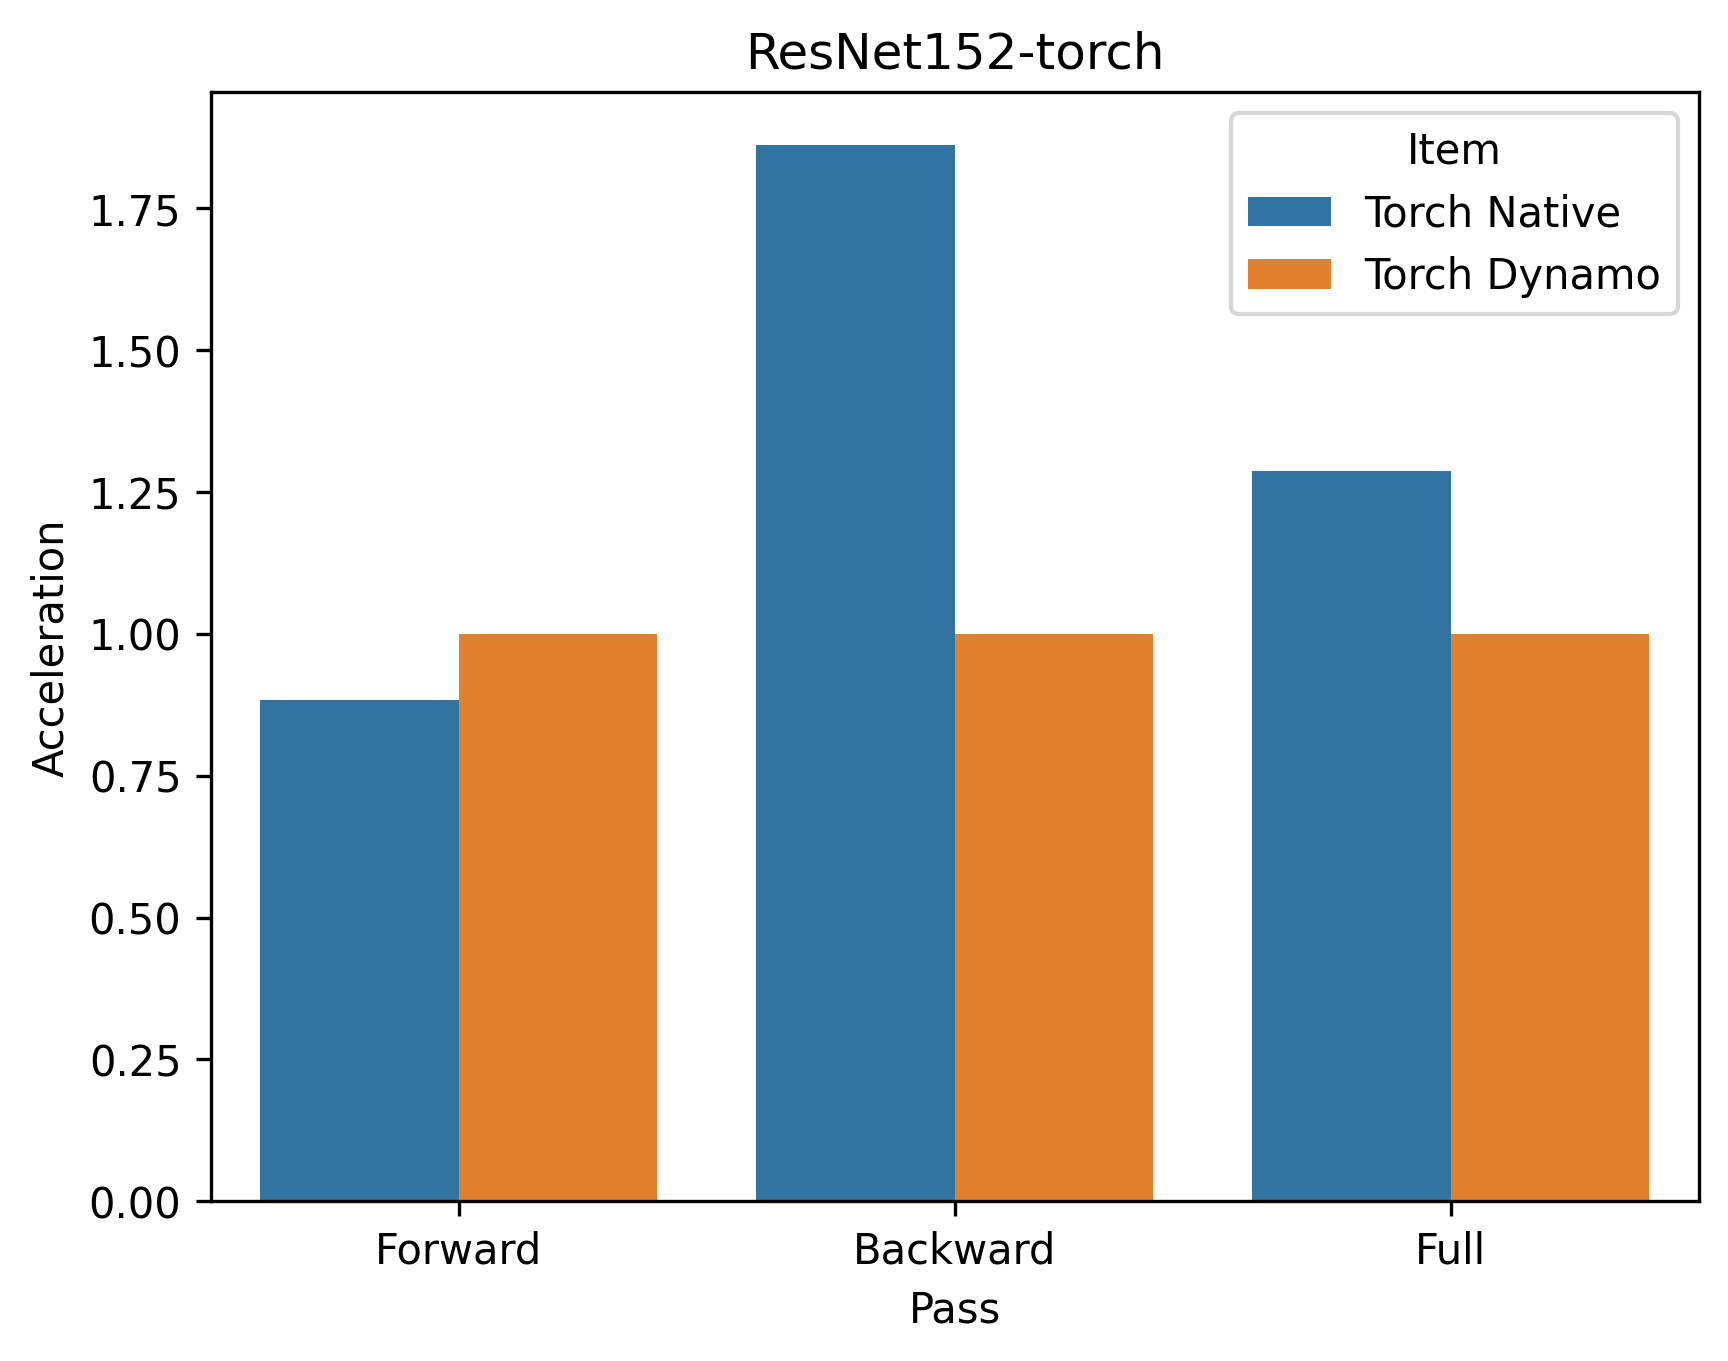

In [11]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")